In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 


In [8]:
df = pd.read_csv("ecommerce_sales.csv")

df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount,Sales,Profit,State,City,Region,Payment_Mode
0,ORD100000,2025-09-28,CUST0107,Coffee Maker,Home & Kitchen,1,3295.12,0.00,3295.115797,698.952467,Rajasthan,Jaipur,North,Cash on Delivery
1,ORD100001,2025-05-30,CUST0309,Headphones,Electronics,2,16946.38,0.15,28808.852279,12094.333473,Maharashtra,Mumbai,West,Cash on Delivery
2,ORD100002,2025-11-10,CUST0022,Smartwatch,Electronics,1,13442.26,0.05,12770.146961,4240.623024,Kerala,Kochi,South,Debit Card
3,ORD100003,2025-11-16,CUST0505,Vacuum Cleaner,Home & Kitchen,2,3774.97,0.10,6794.939549,2119.206966,Tamil Nadu,Chennai,South,Credit Card
4,ORD100004,2025-01-14,CUST0242,Self Help Book,Books,1,750.93,0.05,713.384403,278.727008,Uttar Pradesh,Lucknow,North,Net Banking


In [11]:
df.shape

(5000, 14)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order_ID      5000 non-null   object 
 1   Order_Date    5000 non-null   object 
 2   Customer_ID   5000 non-null   object 
 3   Product       5000 non-null   object 
 4   Category      5000 non-null   object 
 5   Quantity      5000 non-null   int64  
 6   Unit_Price    5000 non-null   float64
 7   Discount      5000 non-null   float64
 8   Sales         5000 non-null   float64
 9   Profit        5000 non-null   float64
 10  State         5000 non-null   object 
 11  City          5000 non-null   object 
 12  Region        5000 non-null   object 
 13  Payment_Mode  5000 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 547.0+ KB


In [13]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Customer_ID     0
Product         0
Category        0
Quantity        0
Unit_Price      0
Discount        0
Sales           0
Profit          0
State           0
City            0
Region          0
Payment_Mode    0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [17]:
df.describe()

,Quantity,Unit_Price,Discount,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.500600,5486.084490,0.075130,7596.718600,2286.380306
std,0.775964,7058.682716,0.058828,11742.119697,3635.121436
min,1.000000,107.030000,0.000000,107.025086,28.490258
25%,1.000000,1330.500000,0.000000,1513.617563,424.195821
50%,1.000000,2153.965000,0.100000,2751.294152,802.234496
75%,2.000000,4221.160000,0.100000,7516.237542,2277.319694
max,4.000000,31113.490000,0.200000,99223.011377,30919.608173


In [19]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [20]:
df["Order_Date"].dtype

dtype('<M8[ns]')

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df = df.drop_duplicates()

In [23]:
df.isnull().sum()

Order_ID        0
Order_Date      0
Customer_ID     0
Product         0
Category        0
Quantity        0
Unit_Price      0
Discount        0
Sales           0
Profit          0
State           0
City            0
Region          0
Payment_Mode    0
dtype: int64

Create Useful Date Columns

In [26]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month
df["Month_Name"] = df["Order_Date"].dt.month_name()

In [27]:
df.head()

,Order_ID,Order_Date,Customer_ID,Product,Category,Quantity,Unit_Price,Discount,Sales,Profit,State,City,Region,Payment_Mode,Year,Month,Month_Name
0,ORD100000,2025-09-28,CUST0107,Coffee Maker,Home & Kitchen,1,3295.12,0.00,3295.115797,698.952467,Rajasthan,Jaipur,North,Cash on Delivery,2025,9,September
1,ORD100001,2025-05-30,CUST0309,Headphones,Electronics,2,16946.38,0.15,28808.852279,12094.333473,Maharashtra,Mumbai,West,Cash on Delivery,2025,5,May
2,ORD100002,2025-11-10,CUST0022,Smartwatch,Electronics,1,13442.26,0.05,12770.146961,4240.623024,Kerala,Kochi,South,Debit Card,2025,11,November
3,ORD100003,2025-11-16,CUST0505,Vacuum Cleaner,Home & Kitchen,2,3774.97,0.10,6794.939549,2119.206966,Tamil Nadu,Chennai,South,Credit Card,2025,11,November
4,ORD100004,2025-01-14,CUST0242,Self Help Book,Books,1,750.93,0.05,713.384403,278.727008,Uttar Pradesh,Lucknow,North,Net Banking,2025,1,January


In [30]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order_ID"].nunique()
total_customers = df["Customer_ID"].nunique()
total_units = df["Quantity"].sum()

profit_margin = (total_profit / total_sales) * 100

print("Total Sales:", round(total_sales, 2))
print("Total Profit:", round(total_profit, 2))
print("Total Orders:", total_orders)
print("Total Customers:", total_customers)
print("Total Units Sold:", total_units)
print("Profit Margin:", round(profit_margin, 2), "%")

Total Sales: 37983593.0
Total Profit: 11431901.53
Total Orders: 5000
Total Customers: 991
Total Units Sold: 7503
Profit Margin: 30.1 %


In [31]:
monthly_sales = df.groupby("Month_Name")["Sales"].sum()

monthly_sales

Month_Name
April        3.176213e+06
August       3.645291e+06
December     3.562565e+06
February     3.223351e+06
January      2.693930e+06
July         3.684567e+06
June         2.785952e+06
March        3.477410e+06
May          3.436455e+06
November     2.646015e+06
October      2.777344e+06
September    2.874499e+06
Name: Sales, dtype: float64

Monthly Sales Analysis 📈

In [32]:
monthly_sales = df.groupby(["Month", "Month_Name"])["Sales"].sum().reset_index()

monthly_sales = monthly_sales.sort_values("Month")

monthly_sales

,Month,Month_Name,Sales
0,1,January,2.693930e+06
1,2,February,3.223351e+06
2,3,March,3.477410e+06
3,4,April,3.176213e+06
4,5,May,3.436455e+06
5,6,June,2.785952e+06
6,7,July,3.684567e+06
7,8,August,3.645291e+06
8,9,September,2.874499e+06
9,10,October,2.777344e+06


first graph 📊

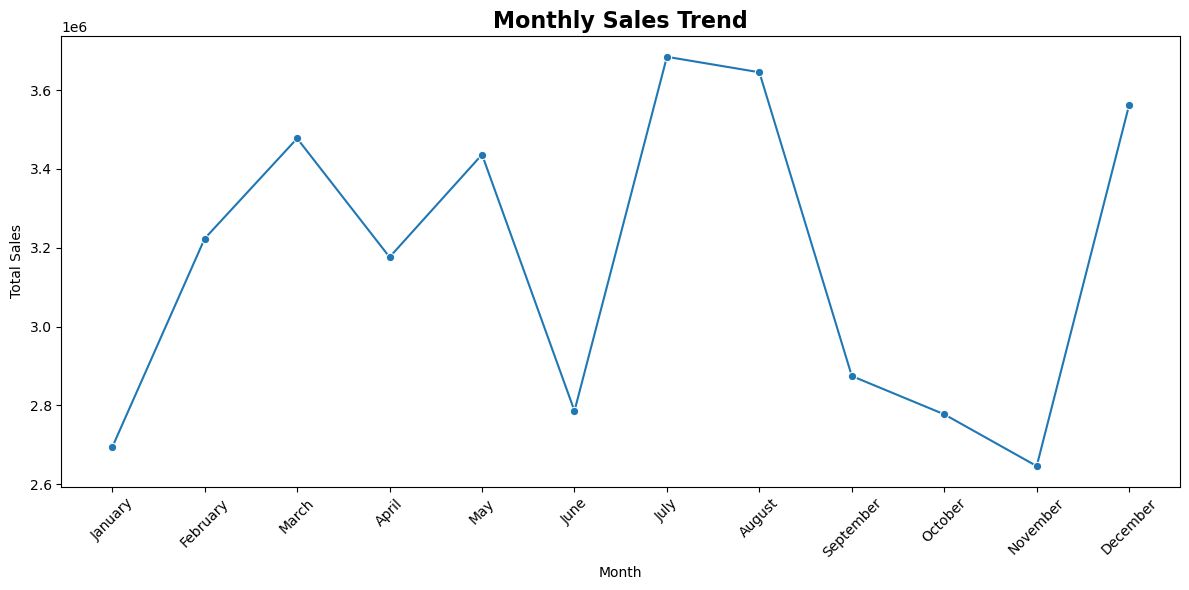

In [33]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_sales,
    x="Month_Name",
    y="Sales",
    marker="o"
)

plt.title("Monthly Sales Trend", fontsize=16, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Category Analysis

In [34]:
category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Units_Sold=("Quantity", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

category_analysis = category_analysis.sort_values(
    "Total_Sales", ascending=False
)

category_analysis

,Category,Total_Sales,Total_Profit,Units_Sold,Orders
2,Electronics,2.726886e+07,8.214473e+06,1629,1088
4,Home & Kitchen,4.414413e+06,1.325968e+06,1388,903
3,Fashion,2.438821e+06,7.330478e+05,1471,993
5,Sports,2.126297e+06,6.348720e+05,1063,732
0,Beauty,1.107313e+06,3.351382e+05,987,657
1,Books,6.278883e+05,1.884024e+05,965,627


Sales by Category 📊

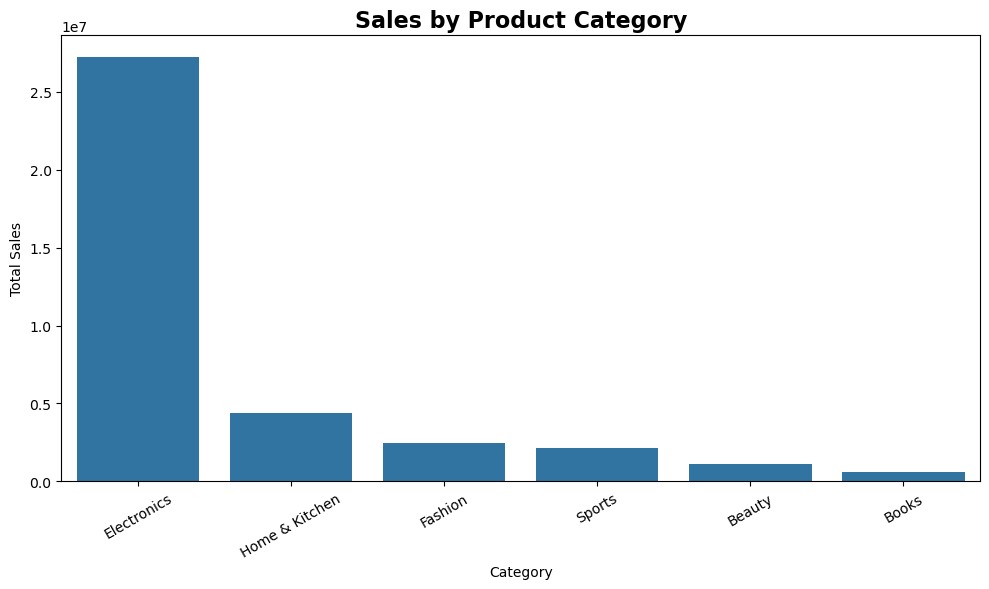

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Total_Sales"
)

plt.title("Sales by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

Profit by Category

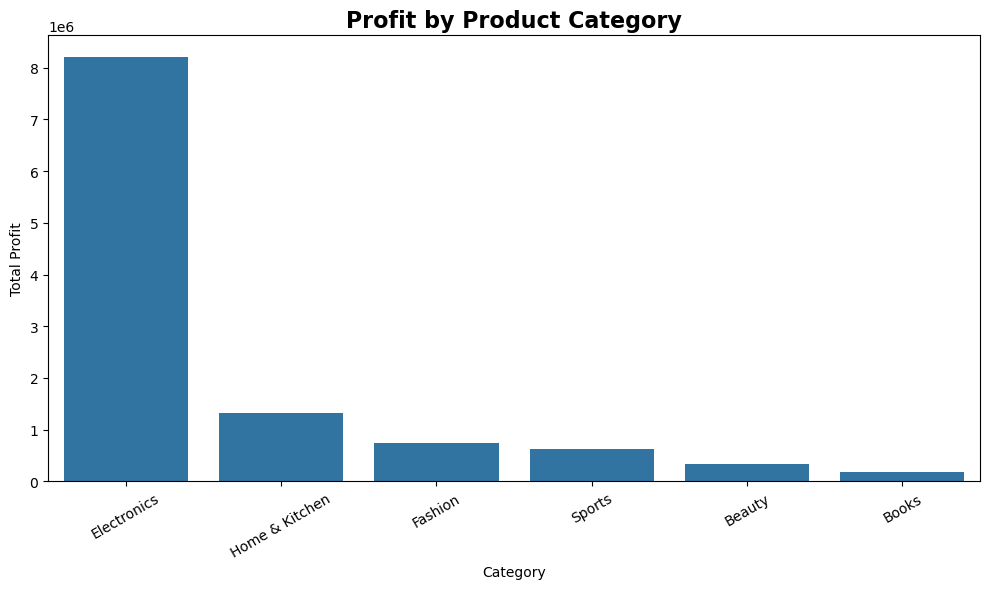

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis,
    x="Category",
    y="Total_Profit"
)

plt.title("Profit by Product Category", fontsize=16, fontweight="bold")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

Found the Top Category

In [37]:
top_sales_category = category_analysis.loc[
    category_analysis["Total_Sales"].idxmax()
]

print("Top Sales Category:", top_sales_category["Category"])
print("Sales:", round(top_sales_category["Total_Sales"], 2))
print("Profit:", round(top_sales_category["Total_Profit"], 2))

Top Sales Category: Electronics
Sales: 27268861.59
Profit: 8214473.36


In [38]:
top_profit_category = category_analysis.loc[
    category_analysis["Total_Profit"].idxmax()
]

print("Top Profit Category:", top_profit_category["Category"])
print("Profit:", round(top_profit_category["Total_Profit"], 2))

Top Profit Category: Electronics
Profit: 8214473.36


Top 10 Products

In [39]:
product_analysis = df.groupby("Product").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Units_Sold=("Quantity", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

product_analysis = product_analysis.sort_values(
    "Total_Sales", ascending=False
)

product_analysis.head(10)

,Product,Total_Sales,Total_Profit,Units_Sold,Orders
24,Smartwatch,5.722936e+06,1.689658e+06,334,216
11,Headphones,5.624289e+06,1.686908e+06,342,222
23,Smartphone,5.488782e+06,1.702547e+06,331,221
14,Laptop,5.273058e+06,1.614415e+06,314,221
27,Tablet,5.159797e+06,1.520944e+06,308,208
16,Mixer Grinder,1.038221e+06,3.084027e+05,328,196
3,Cookware Set,8.891860e+05,2.774351e+05,281,182
0,Air Fryer,8.646618e+05,2.566160e+05,270,174
28,Vacuum Cleaner,8.332197e+05,2.426341e+05,257,174
2,Coffee Maker,7.891240e+05,2.408799e+05,252,177


Top 10 Products Chart 📊

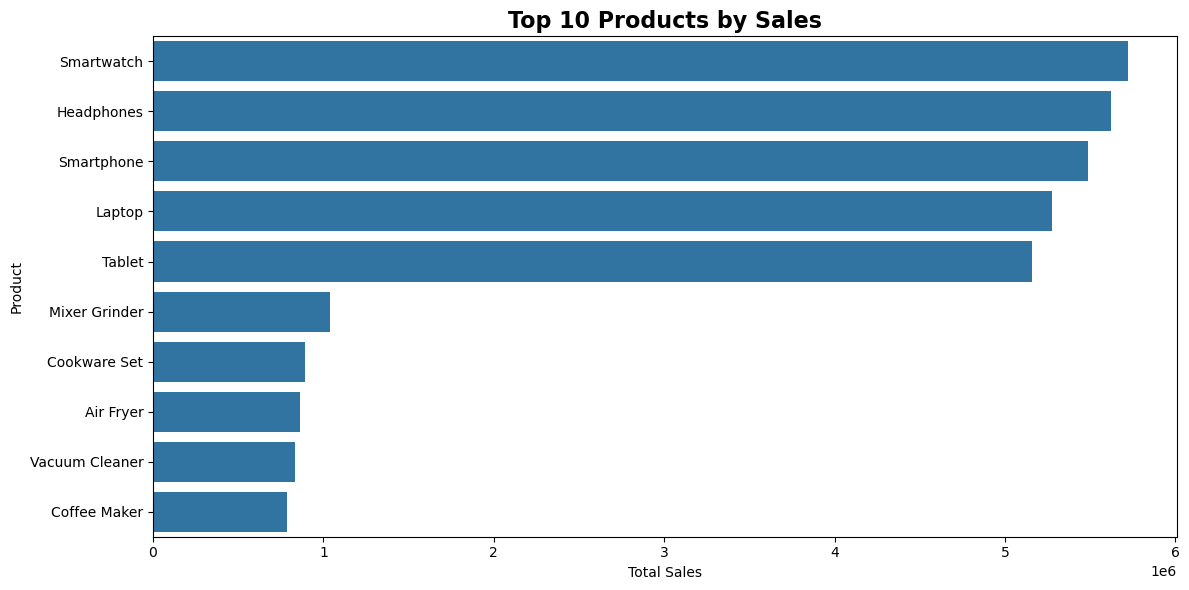

In [40]:
top_10_products = product_analysis.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_products,
    x="Total_Sales",
    y="Product"
)

plt.title("Top 10 Products by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()

plt.show()

Top 10 Customers 👥

In [41]:
customer_analysis = df.groupby("Customer_ID").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique"),
    Units_Sold=("Quantity", "sum")
).reset_index()

customer_analysis = customer_analysis.sort_values(
    "Total_Sales", ascending=False
)

customer_analysis.head(10)

,Customer_ID,Total_Sales,Total_Profit,Orders,Units_Sold
878,CUST0886,281485.556455,87997.444281,11,23
856,CUST0863,176934.873908,45442.344843,5,14
457,CUST0463,167986.459566,50323.264632,9,17
429,CUST0435,163112.485610,53616.542990,11,16
331,CUST0337,151330.230152,55135.922197,7,11
496,CUST0502,139223.566567,45660.867010,8,15
871,CUST0878,138415.373662,45986.882501,9,15
544,CUST0550,133535.967774,35348.527226,10,18
522,CUST0528,133040.918698,41666.275762,9,15
232,CUST0238,131964.468626,37484.189045,7,11


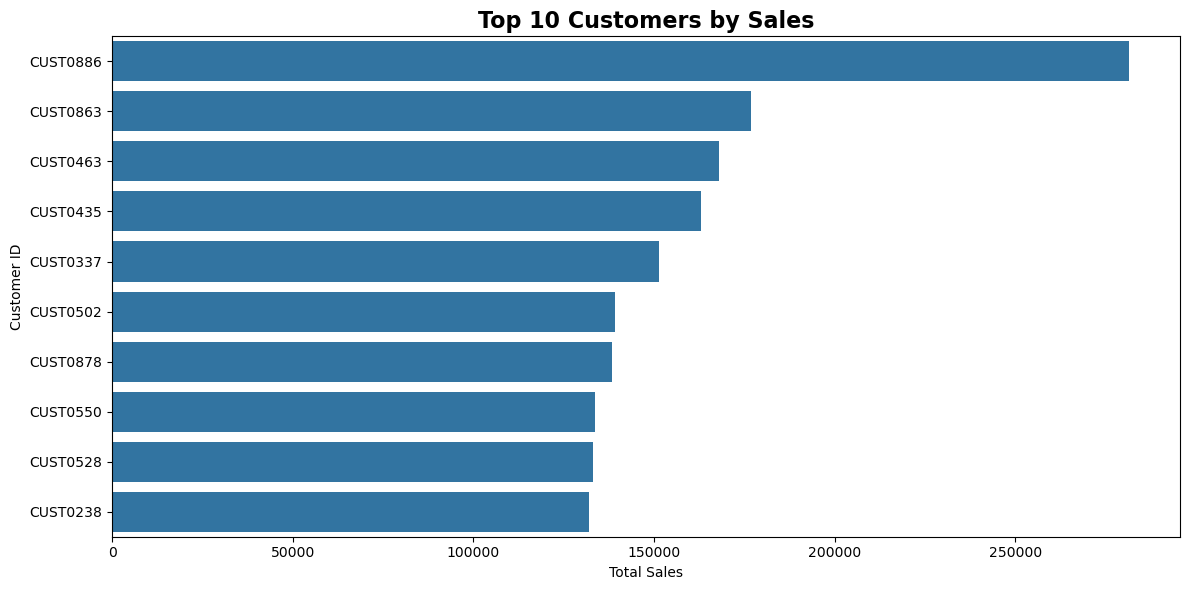

In [42]:
top_10_customers = customer_analysis.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_10_customers,
    x="Total_Sales",
    y="Customer_ID"
)

plt.title("Top 10 Customers by Sales", fontsize=16, fontweight="bold")
plt.xlabel("Total Sales")
plt.ylabel("Customer ID")
plt.tight_layout()

plt.show()

Regional Analysis 🌍

In [43]:
region_analysis = df.groupby("Region").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique"),
    Units_Sold=("Quantity", "sum")
).reset_index()

region_analysis = region_analysis.sort_values(
    "Total_Sales", ascending=False
)

region_analysis

,Region,Total_Sales,Total_Profit,Orders,Units_Sold
2,South,1.503800e+07,4.499741e+06,1985,2949
1,North,1.253148e+07,3.771575e+06,1558,2388
3,West,7.027285e+06,2.108228e+06,971,1461
0,East,3.386833e+06,1.052357e+06,486,705


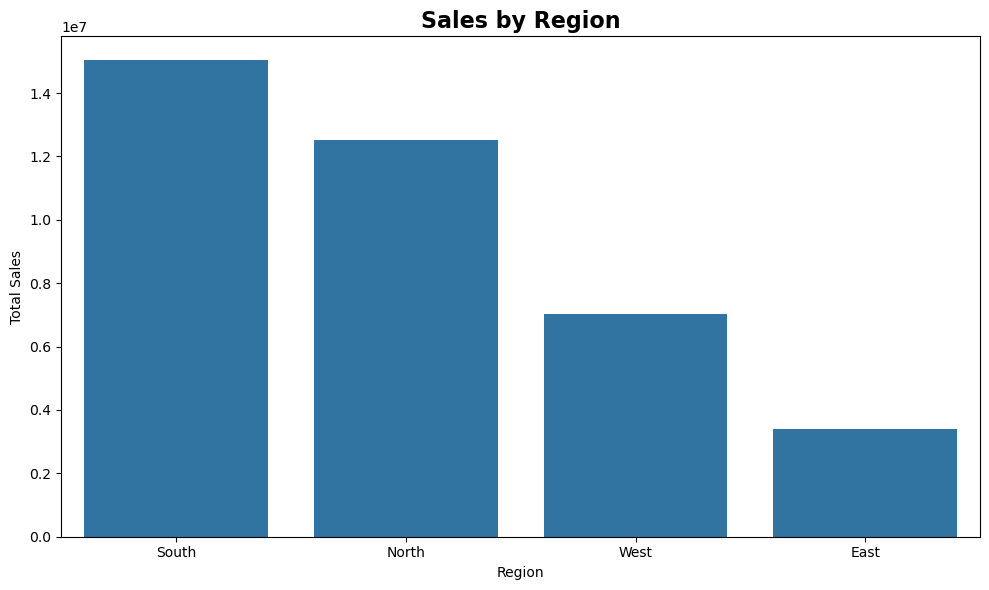

In [44]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Total_Sales"
)

plt.title("Sales by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.tight_layout()

plt.show()

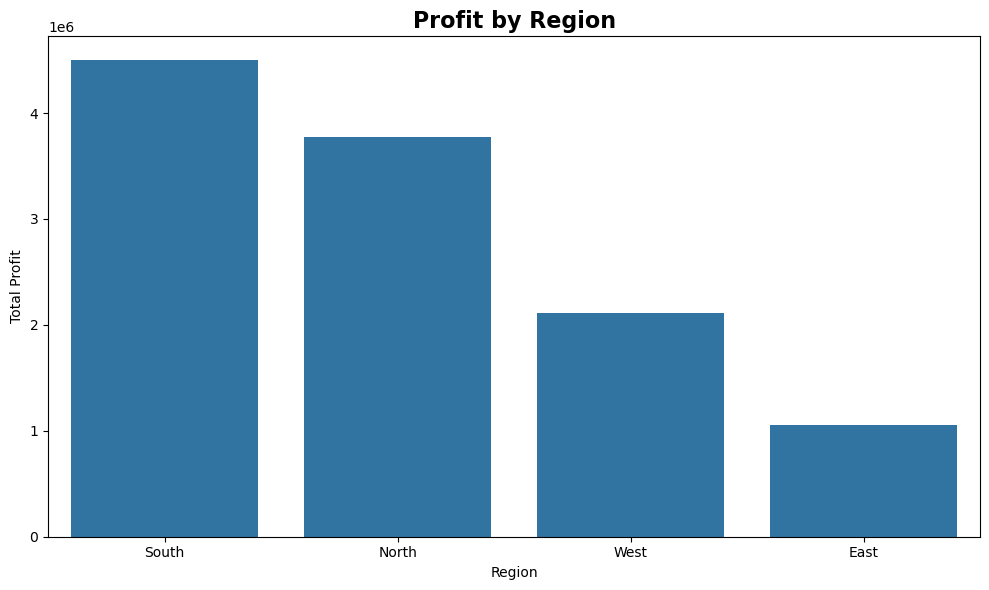

In [54]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=region_analysis,
    x="Region",
    y="Total_Profit"
)

plt.title("Profit by Region", fontsize=16, fontweight="bold")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.tight_layout()

plt.show()

In [46]:
payment_analysis = df.groupby("Payment_Mode").agg(
    Total_Sales=("Sales", "sum"),
    Total_Orders=("Order_ID", "nunique")
).reset_index()

payment_analysis = payment_analysis.sort_values(
    "Total_Sales", ascending=False
)

payment_analysis

,Payment_Mode,Total_Sales,Total_Orders
1,Credit Card,8.398131e+06,1042
4,UPI,7.714096e+06,987
2,Debit Card,7.550319e+06,961
0,Cash on Delivery,7.200685e+06,986
3,Net Banking,7.120363e+06,1024


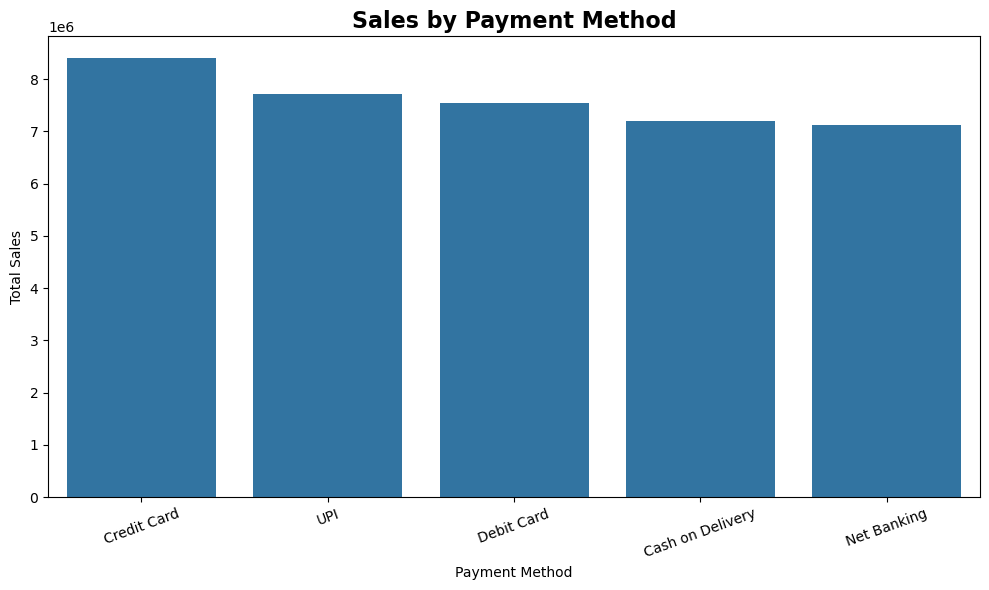

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_analysis,
    x="Payment_Mode",
    y="Total_Sales"
)

plt.title("Sales by Payment Method", fontsize=16, fontweight="bold")
plt.xlabel("Payment Method")
plt.ylabel("Total Sales")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

discount analysis

In [49]:
df["Discount_Band"] = pd.cut(
    df["Discount"],
    bins=[-0.01, 0, 0.05, 0.10, 0.15, 0.20],
    labels=["0%", "1-5%", "6-10%", "11-15%", "16-20%"]
)

In [50]:
df[["Discount", "Discount_Band"]].head(10)

,Discount,Discount_Band
0,0.00,0%
1,0.15,11-15%
2,0.05,1-5%
3,0.10,6-10%
4,0.05,1-5%
5,0.10,6-10%
6,0.10,6-10%
7,0.10,6-10%
8,0.05,1-5%
9,0.10,6-10%


In [51]:
discount_analysis = df.groupby(
    "Discount_Band",
    observed=False
).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Orders=("Order_ID", "nunique")
).reset_index()

discount_analysis

,Discount_Band,Total_Sales,Total_Profit,Orders
0,0%,1.077140e+07,3.211822e+06,1285
1,1-5%,9.439180e+06,2.852751e+06,1212
2,6-10%,1.091957e+07,3.304236e+06,1463
3,11-15%,5.211086e+06,1.569994e+06,785
4,16-20%,1.642350e+06,4.930987e+05,255


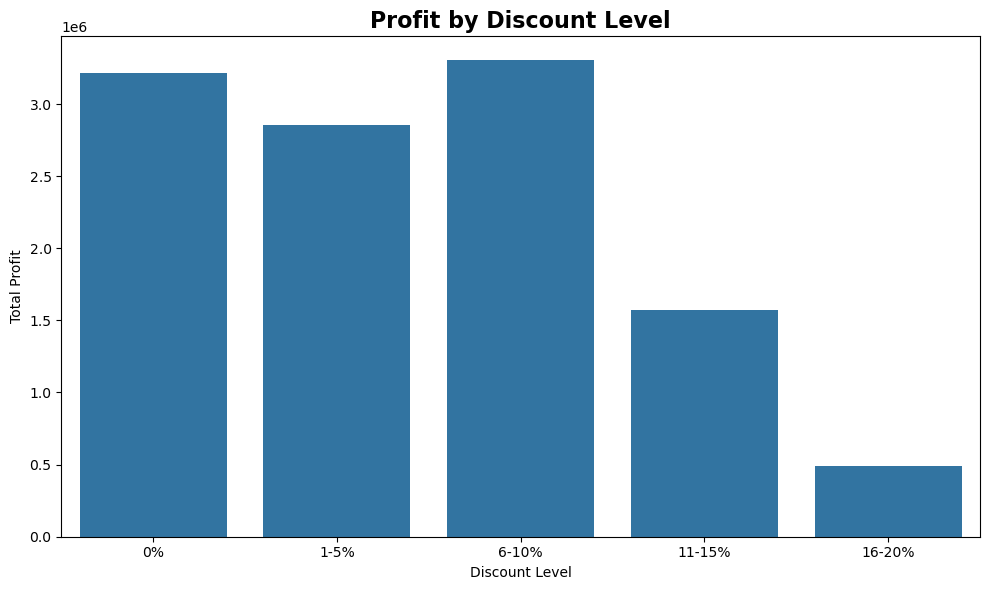

In [52]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=discount_analysis,
    x="Discount_Band",
    y="Total_Profit"
)

plt.title("Profit by Discount Level", fontsize=16, fontweight="bold")
plt.xlabel("Discount Level")
plt.ylabel("Total Profit")
plt.tight_layout()

plt.show()

In [53]:
df.to_csv("ecommerce_sales_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
